In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import warnings
warnings.filterwarnings("ignore")
import sys
sys.path.append('/home/future_commodity')
import pandas as pd
import numpy as np
np.seterr(all='ignore')
import lightgbm as lgb
from pathlib import Path
import os
from typing import List, Tuple
import function_future.pre_train as pt
import function_future.train_model as tm
import function_future.FactorFilter as FF
import function_future.backtest_v3 as bv
import function_future.DataLoader as DL, function_future.date_selection as DS
import function_future.trading_visualization as TV
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from joblib import Parallel, delayed
import re


In [3]:
train_end_date = '2025-07-01'
symbol = 'OI'
folder_name = f'{symbol}_pred5_2025-07-01_v0'
train_label = 5
rtn_mul = 1
config_loader = DL.InstrumentConfig()
config_loader.get_instrument_config(symbol)

{'symbol': 'OI',
 'contract_multiplier': 10,
 'price_tick': 1,
 'margin_rate': 0.09,
 'fee': 2,
 'fee_way': 'number',
 'fee_comment': '无',
 'trading_hours': ['09:00-11:30', '13:30-15:00', '21:00-23:00'],
 'light': 1,
 'night': 1,
 'exchange': 'czce',
 'name': '菜籽油'}

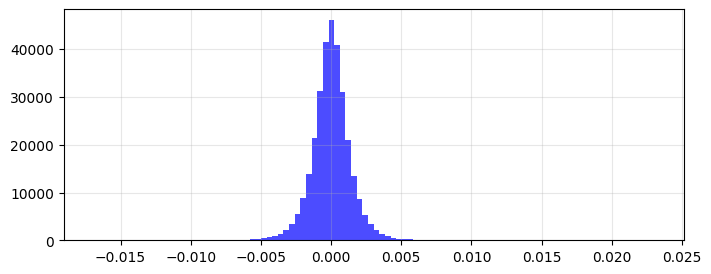


Fold 1/5
Fold 1 验证集日期范围: 2021-02-01 09:11:00 至 2021-12-23 14:11:00
Fold 1 训练集样本数: 246423, 验证集样本数: 61606
Training until validation scores don't improve for 500 rounds
[100]	valid_0's l2: 0.992972
[200]	valid_0's l2: 0.993018
[300]	valid_0's l2: 0.993053
[400]	valid_0's l2: 0.993118
[500]	valid_0's l2: 0.993171
Early stopping, best iteration is:
[7]	valid_0's l2: 0.992943


<Figure size 1000x600 with 0 Axes>

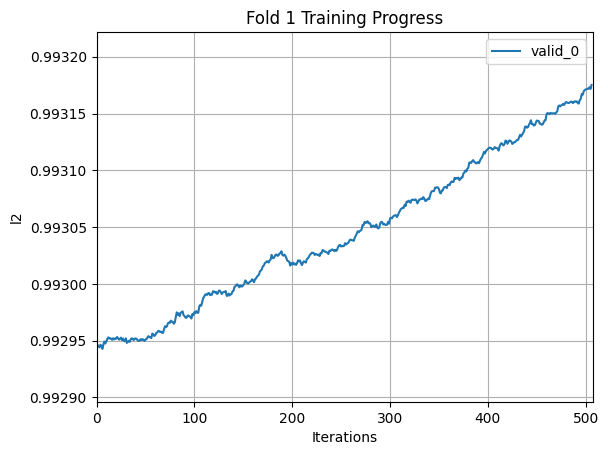

valid ic: 0.002401775367572871
模型最佳迭代次数 = 7

Fold 2/5
Fold 2 验证集日期范围: 2021-12-23 14:12:00 至 2022-11-09 13:51:00
Fold 2 训练集样本数: 246423, 验证集样本数: 61606
Training until validation scores don't improve for 500 rounds
[100]	valid_0's l2: 0.992231
[200]	valid_0's l2: 0.992291
[300]	valid_0's l2: 0.992382
[400]	valid_0's l2: 0.992508
[500]	valid_0's l2: 0.992649
Early stopping, best iteration is:
[31]	valid_0's l2: 0.992219


<Figure size 1000x600 with 0 Axes>

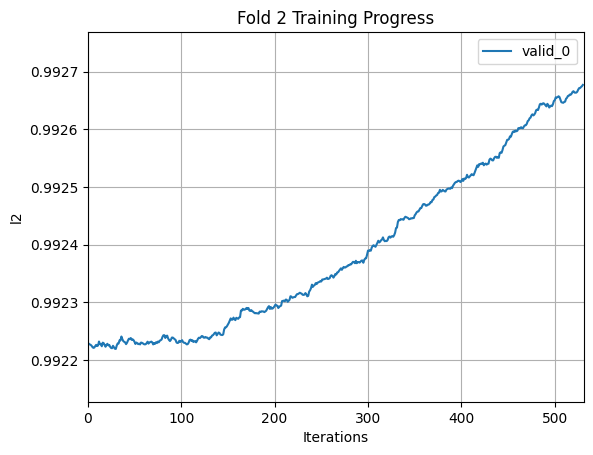

valid ic: 0.004971703355251159
模型最佳迭代次数 = 31

Fold 3/5
Fold 3 验证集日期范围: 2022-11-09 13:52:00 至 2023-09-22 21:45:00
Fold 3 训练集样本数: 246423, 验证集样本数: 61606
Training until validation scores don't improve for 500 rounds
[100]	valid_0's l2: 0.992667
[200]	valid_0's l2: 0.992655
[300]	valid_0's l2: 0.992662
[400]	valid_0's l2: 0.992627
[500]	valid_0's l2: 0.992613
[600]	valid_0's l2: 0.992598
[700]	valid_0's l2: 0.992596
[800]	valid_0's l2: 0.992583
[900]	valid_0's l2: 0.99257
[1000]	valid_0's l2: 0.992565
[1100]	valid_0's l2: 0.992557
[1200]	valid_0's l2: 0.992541
[1300]	valid_0's l2: 0.992535
[1400]	valid_0's l2: 0.992554
[1500]	valid_0's l2: 0.992558
[1600]	valid_0's l2: 0.992536
[1700]	valid_0's l2: 0.99254
[1800]	valid_0's l2: 0.992534
[1900]	valid_0's l2: 0.992541
[2000]	valid_0's l2: 0.992526
[2100]	valid_0's l2: 0.992527
[2200]	valid_0's l2: 0.992541
[2300]	valid_0's l2: 0.99253
[2400]	valid_0's l2: 0.992549
[2500]	valid_0's l2: 0.992545
Early stopping, best iteration is:
[2067]	valid_0'

<Figure size 1000x600 with 0 Axes>

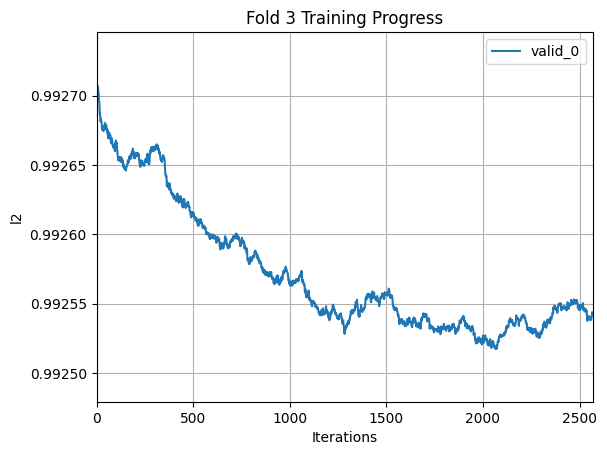

valid ic: 0.014226367782735196
模型最佳迭代次数 = 2067

Fold 4/5
Fold 4 验证集日期范围: 2023-09-22 21:46:00 至 2024-08-15 09:31:00
Fold 4 训练集样本数: 246423, 验证集样本数: 61606
Training until validation scores don't improve for 500 rounds
[100]	valid_0's l2: 0.992118
[200]	valid_0's l2: 0.992067
[300]	valid_0's l2: 0.992023
[400]	valid_0's l2: 0.991973
[500]	valid_0's l2: 0.991941
[600]	valid_0's l2: 0.991911
[700]	valid_0's l2: 0.991891
[800]	valid_0's l2: 0.991896
[900]	valid_0's l2: 0.991889
[1000]	valid_0's l2: 0.99188
[1100]	valid_0's l2: 0.991863
[1200]	valid_0's l2: 0.99186
[1300]	valid_0's l2: 0.991866
[1400]	valid_0's l2: 0.991853
[1500]	valid_0's l2: 0.991849
[1600]	valid_0's l2: 0.991838
[1700]	valid_0's l2: 0.991854
[1800]	valid_0's l2: 0.991857
[1900]	valid_0's l2: 0.991861
[2000]	valid_0's l2: 0.991873
Early stopping, best iteration is:
[1599]	valid_0's l2: 0.991837


<Figure size 1000x600 with 0 Axes>

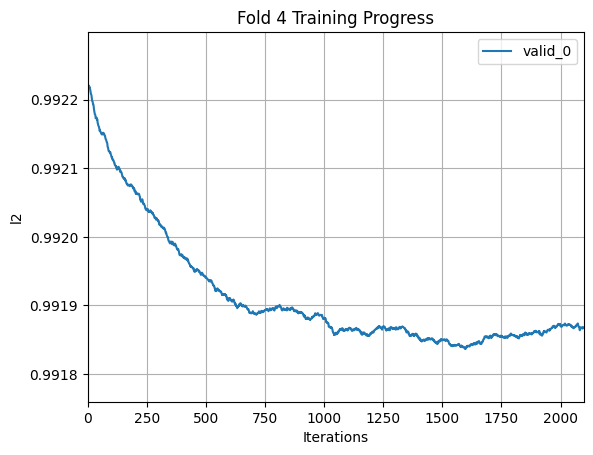

valid ic: 0.02055579111592029
模型最佳迭代次数 = 1599

Fold 5/5
Fold 5 验证集日期范围: 2024-08-15 09:32:00 至 2025-07-01 22:49:00
Fold 5 训练集样本数: 246424, 验证集样本数: 61605
Training until validation scores don't improve for 500 rounds
[100]	valid_0's l2: 0.992198
[200]	valid_0's l2: 0.992224
[300]	valid_0's l2: 0.99226
[400]	valid_0's l2: 0.992304
[500]	valid_0's l2: 0.992326
Early stopping, best iteration is:
[58]	valid_0's l2: 0.992193


<Figure size 1000x600 with 0 Axes>

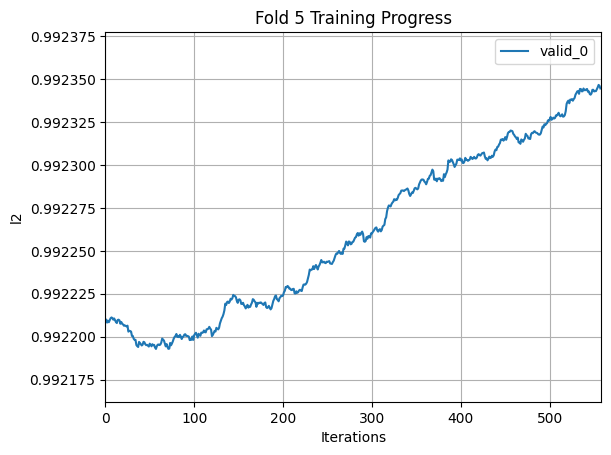

valid ic: 0.005546047279041934
模型最佳迭代次数 = 58
特征重要性已保存到 /mnt/Data/writable/liaoyuyang/factor_eval_commodity/2025-07-01/importance/2025-07-01_OI_5_feature_importance_reg.csv
特征相关系数表已保存到 /mnt/Data/writable/liaoyuyang/factor_eval_commodity/2025-07-01/correlation/2025-07-01_OI_5_feature_corr.csv
因子组别表已保存到 /mnt/Data/writable/liaoyuyang/factor_eval_commodity/2025-07-01/group/2025-07-01_OI_5_feature_group.csv
最后两列 Index(['pred_ret', 'hour'], dtype='object')


In [4]:
fac_df = pd.read_feather(f'/mnt/Data/writable/liaoyuyang/factor/{symbol}/all_fac/all_factor.feather').set_index(['datetime']).loc[:train_end_date]
fac_df = config_loader.df_cut_time(fac_df, config_loader.get_instrument_config(symbol)['trading_hours'], 10)

exclude_factors = [
        'datetime', 'instrument',
        ]

factor_col = [x for x in fac_df.columns if x not in exclude_factors]

main_fac_piv = fac_df[factor_col]
rtn_df = pd.read_csv(f'/mnt/Data/writable/liaoyuyang/data/1min/active/main_{symbol}.csv', index_col=0, parse_dates=['ts']).set_index('ts').reindex(index=fac_df.index)
main_fac_piv['pred_ret'] = rtn_df[f'rtn_{train_label}']
main_fac_piv = main_fac_piv.replace([np.inf, -np.inf], np.nan)
main_fac_piv['hour'] = main_fac_piv.index.hour

main_fac_piv['pred_ret'].hist(bins=100, figsize=(8, 3), alpha=0.7, color='blue')
plt.grid(True, alpha=0.3)
plt.show()

pretrainer = pt.Pretrainer(symbol, main_fac_piv, train_end_date, train_label=train_label)

importance = pretrainer.run_full_pretraining(type_lgb = 'reg')

In [5]:
factor_info = pd.read_csv(f'/mnt/Data/writable/liaoyuyang/factor_eval_commodity/{train_end_date}/{symbol}_single_factor_eval_{train_label}.csv', index_col=0)
importance_df = pd.read_csv(f'/mnt/Data/writable/liaoyuyang/factor_eval_commodity/{train_end_date}/importance/{train_end_date}_{symbol}_{train_label}_feature_importance_reg.csv')
corr_df = pd.read_csv(f'/mnt/Data/writable/liaoyuyang/factor_eval_commodity/{train_end_date}/correlation/{train_end_date}_{symbol}_{train_label}_feature_corr.csv', index_col=0)
group_df = pd.read_csv(f'/mnt/Data/writable/liaoyuyang/factor_eval_commodity/{train_end_date}/group/{train_end_date}_{symbol}_{train_label}_feature_group.csv')
factor_to_choose = main_fac_piv.columns[:-1]

factor_filter = FF.FactorFilter(importance_df, corr_df, group_df, factor_info, factor_to_choose)
print([x for x in factor_filter.factor_to_choose if x not in factor_info.index])
params = {
    "info_select_params": {"nan_rate": 0.8, "mode_rate": 0.9},
    "importance_select_by_group_params" : {"cut_num_1": 300, "cut_num_2":200, "same_name_cut": 5}, 
    "corr_select_params": {"feature_num_limit": 300, "corr_limit": 0.9}, 
    "sp_select": {"th":0.5},
    "day_cut": {"num_limit":5},
    "exclude_factors": [
            'datetime', 'instrument',
            'JC1D', 'ZCpriceinterval', 'ptvol5',
            'JC2H'
            ]
}
factor_filter.run_selection(**params)

lst1 = [x for x in factor_filter.factor_to_choose if x.startswith('FAC')]
lst2 = [x for x in factor_filter.factor_to_choose if x.startswith('STK')]
lst3 = [x for x in factor_filter.factor_to_choose if re.match(r'^(_P|P_|_M|M_|A_|_A|_OI|OI_|_Y|Y_|_RM|RM_)', x)]
lst4 = [x for x in factor_filter.factor_to_choose if x not in lst1+lst2+lst3]
len(lst1), len(lst2), len(lst3), len(lst4)

['FAC_Depth_Reversal_downmean', 'FAC_Depth_Reversal_upmean', 'pred_ret']
特征分布性过滤：
筛选之前因子数量：1857， 筛选之后因子数量：1802

特征重要性过滤： 300 200 	待筛因子个数 1802
无向因子有效个数： 1071 有向因子有效个数： 750
  选择有向特征 218 个，重要性范围: 1318.00 - 30.00
  选择无向特征 139 个，重要性范围: 1018.00 - 41.00

单因子sharpe过滤： 0.5 sp范围-6.9328 ~ 11.3884   待筛因子个数 357

特征相关性性过滤： 300     待筛因子个数 290
  选择特征 238 个, 特征最大相关性0.8992841888642616

已挑选日频开盘因子数量： 5 ['day_first4greencorr', 'day_jump', 'day_first3power', 'day_first4redcorr', 'day_first10colarrate']

保留日频开盘因子数量： 5 ['day_first4greencorr', 'day_jump', 'day_first3power', 'day_first4redcorr', 'day_first10colarrate']

排除指定因子后，剩余特征 236 个


(184, 0, 24, 28)

正在从 /mnt/Data/writable/liaoyuyang/factor/OI/all_fac/all_factor.feather 加载数据...
训练数据加载完成，形状: (307726, 1861)
训练集时间范围: 2021-02-01 09:11:00 至 2025-06-30 22:49:00
[200]	valid_0's rmse: 0.996561
[400]	valid_0's rmse: 0.996671


<Figure size 1000x600 with 0 Axes>

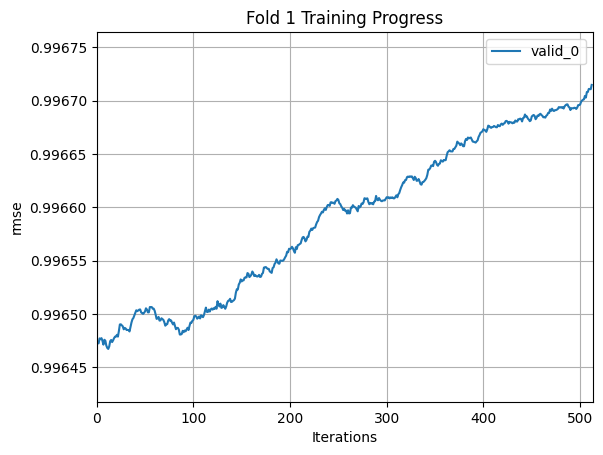

{'train_rmse': np.float64(0.9998118171681382), 'val_rmse': np.float64(1.0003756450854584), 'best_iteration': 13}
test_corr: -0.0096
[200]	valid_0's rmse: 0.996001
[400]	valid_0's rmse: 0.996079
[600]	valid_0's rmse: 0.996224


<Figure size 1000x600 with 0 Axes>

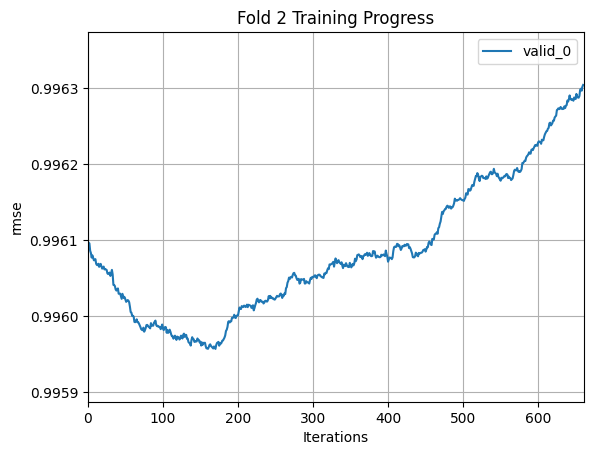

{'train_rmse': np.float64(0.9982426904327403), 'val_rmse': np.float64(0.9998636708719575), 'best_iteration': 161}
test_corr: -0.0016
[200]	valid_0's rmse: 0.996309
[400]	valid_0's rmse: 0.996281
[600]	valid_0's rmse: 0.996246
[800]	valid_0's rmse: 0.996259
[1000]	valid_0's rmse: 0.996283


<Figure size 1000x600 with 0 Axes>

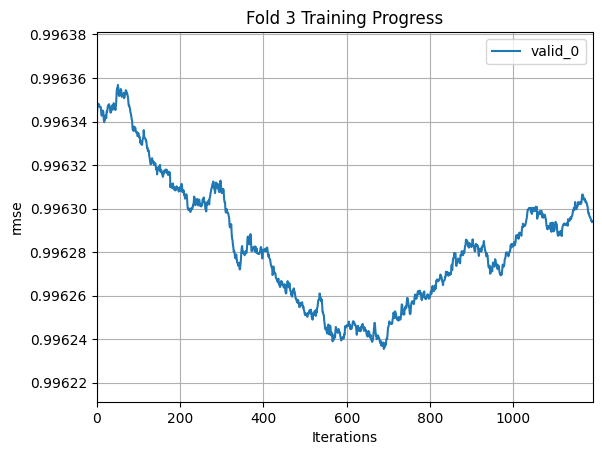

{'train_rmse': np.float64(0.9934790438260329), 'val_rmse': np.float64(1.0001427816982624), 'best_iteration': 690}
test_corr: -0.0100
[200]	valid_0's rmse: 0.995971
[400]	valid_0's rmse: 0.995921
[600]	valid_0's rmse: 0.995886
[800]	valid_0's rmse: 0.995858
[1000]	valid_0's rmse: 0.995847
[1200]	valid_0's rmse: 0.995871
[1400]	valid_0's rmse: 0.995878


<Figure size 1000x600 with 0 Axes>

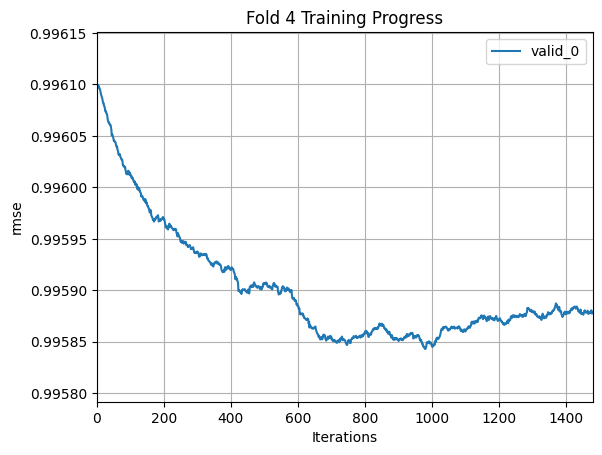

{'train_rmse': np.float64(0.9911393469552403), 'val_rmse': np.float64(0.9997493536071378), 'best_iteration': 980}
test_corr: 0.0006
[200]	valid_0's rmse: 0.996111
[400]	valid_0's rmse: 0.99615
[600]	valid_0's rmse: 0.996198


<Figure size 1000x600 with 0 Axes>

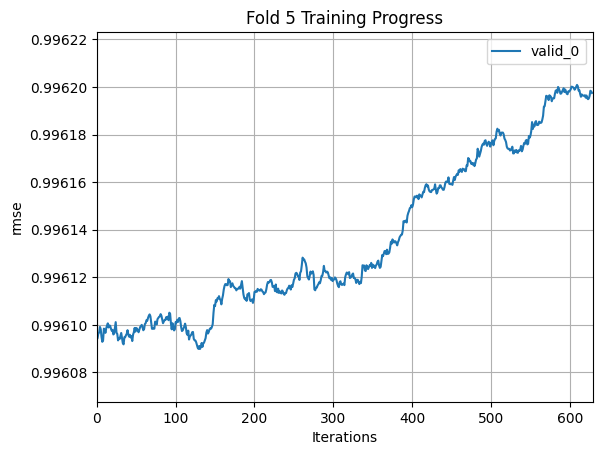

{'train_rmse': np.float64(0.9983425852210198), 'val_rmse': np.float64(0.9999963192993222), 'best_iteration': 129}
test_corr: -0.0103


In [6]:
analyzer = tm.TimeSeriesAnalyzer(
    symbol = symbol,
    factor_col = factor_filter.factor_to_choose,
    train_end_date = train_end_date,
    config_loader = config_loader
)
analyzer.load_and_prepare_data(log_rtn=True, set_category_col=['hour'], label_col=f'rtn_{train_label}', cut=True)
trainer = tm.LGBMTrainer(analyzer)
_ = trainer.train_kfold_v0(custom_params={'verbose':-1}, model_folder_name=folder_name, plot_train=True, n_splits=5)

In [7]:
config = bv.load_config(r"/mnt/Data/writable/liaoyuyang/backtest/backtest_config.json")
config['MODEL_DIR'] = Path(config['MODEL_DIR']) / str(folder_name)
config

{'MODEL_DIR': PosixPath('/mnt/Data/writable/liaoyuyang/model/lightgbm/KFoldModel/models/OI_pred5_2025-07-01_v0'),
 'OUTPUT_DIR': '/mnt/Data/writable/liaoyuyang/backtest/results',
 'pic_dir': '/mnt/Data/writable/liaoyuyang/backtest/pic',
 'feature_dir': '/mnt/Data/writable/liaoyuyang/backtest/data/features',
 'pred_label_dir': '/mnt/Data/writable/liaoyuyang/backtest/data/predictions',
 'merged_output_dir': '/mnt/Data/writable/liaoyuyang/backtest/data/merged',
 'start_date': '20180101',
 'end_date': '20260101',
 'ts_col': 'datetime',
 'instrument_col': 'instrument',
 'target_col': 'pred_ret',
 'holding_price_col': 'close',
 'trading_price_col': 'tick6t60avg',
 'pos_col': 'pos',
 'category_col': ['hour'],
 'factor_col': 'factor',
 'filter_dict': {'exclude_night': True},
 'auto_create_dirs': True}

In [8]:
bt = bv.ModelBacktester(train_end_date, config)
bt.load_config(symbol)
bt.window_end = '2027-01-01'
bt.money = 50_000 
bt.fee = 0

bt.load_factor(symbol, end_date=bt.window_end)
bt.load_mktdata(symbol, end_date=bt.window_end)
bt.load_models()
bt.generate_predictions()
pred = bt.combine_models('best_iteration_log_weighted', avg=True)

In [9]:
merged_data = bt.backtest(th1=0.9, th2=0.5, save=False, open_drop=True, holding_bars=10,
                           day=5*345, model_name='best_iteration_log_weighted', v=2
                        )

trading_hours ['09:00-11:30', '13:30-15:00', '21:00-23:00']


  0%|          | 0/36093 [00:00<?, ?it/s]

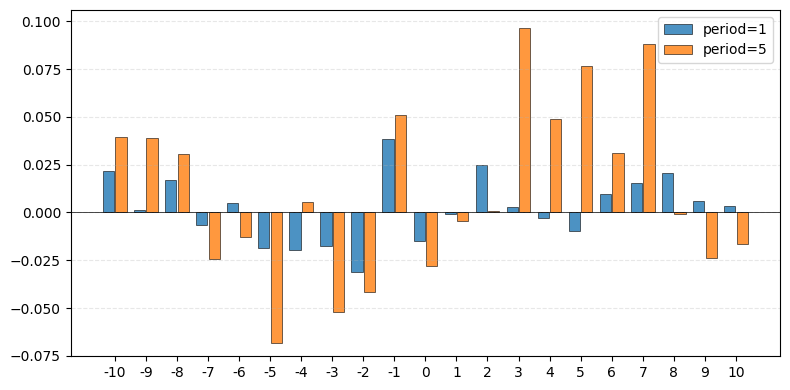

In [10]:
fig = bv.plot_group_bar(merged_data, periods=[1,5], trading_hours=["09:00-11:30", "13:30-15:00", "21:00-23:00"], g=21)

In [11]:
bv.analyze_pos_distribution(merged_data)

,统计值
多头(+1) 数量,8138
空头(-1) 数量,6901
空仓(0) 数量,21056
多头占比,22.55%
空头占比,19.12%
空仓占比,58.33%
交易日数量,107
总收益(非年化%),18.29
总交易次数（开平算一次）,1084
每笔收益(%%),1.69


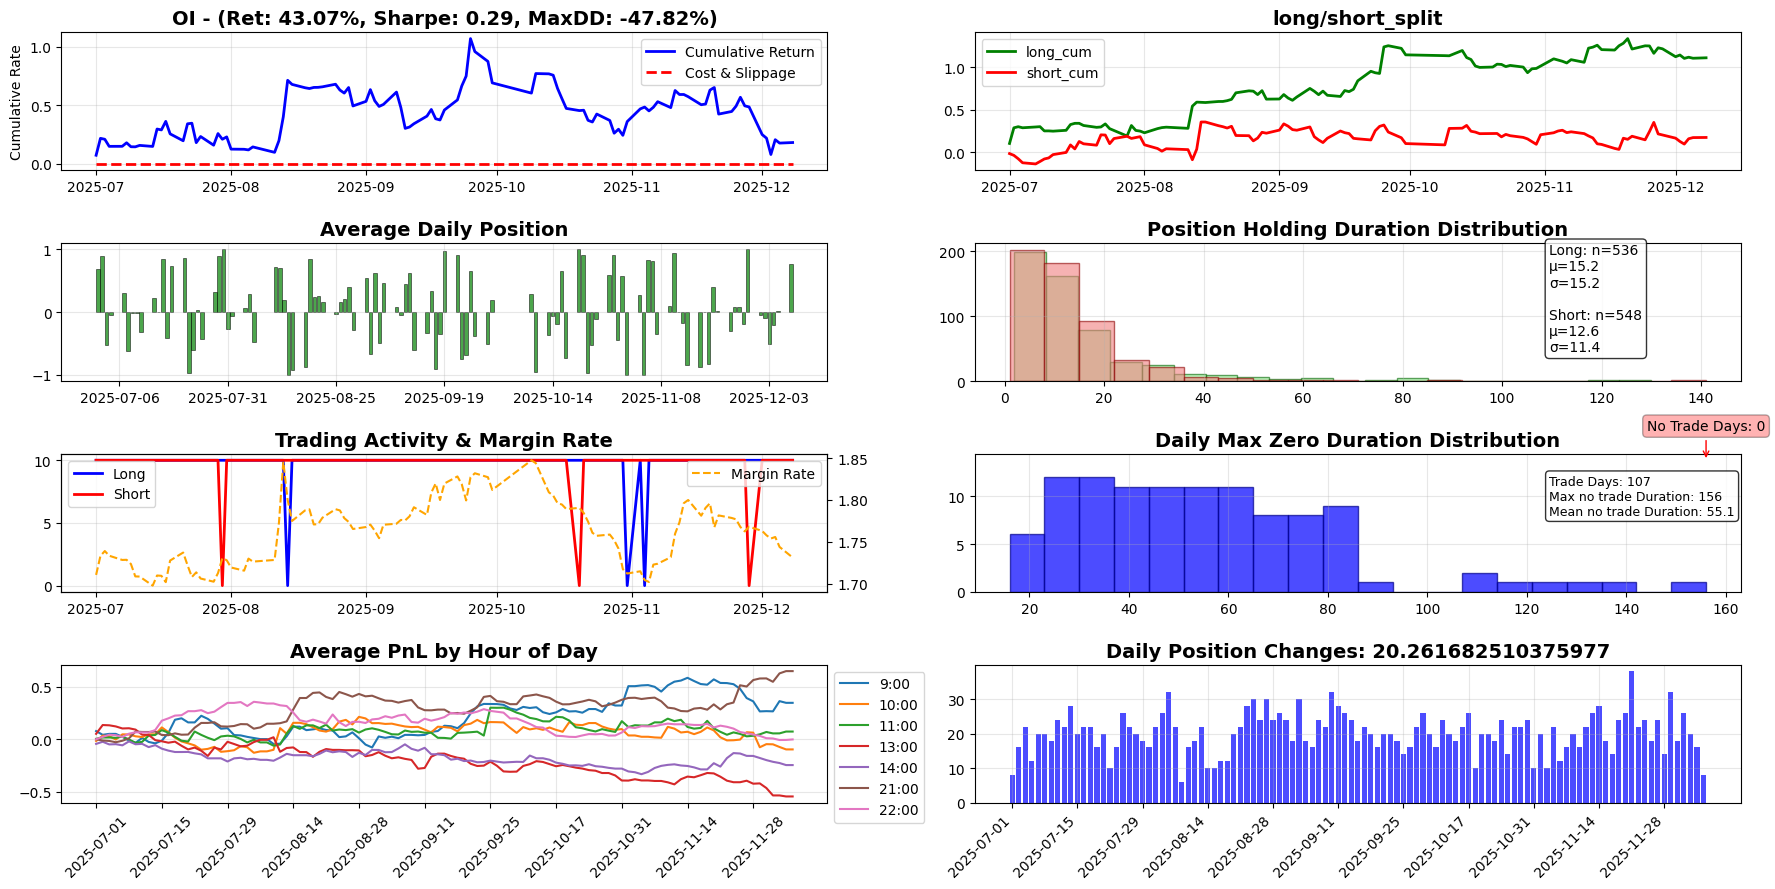

In [12]:
fig = bv.plot_eval(symbol, merged_data, "无")

In [13]:
tvp = TV.TradingVisualizationPager(symbol=symbol, data = merged_data, skip_weekends=True)
tvp.run()

Output()

✅ 交易可视化工具已启动
📈 品种: OI
📅 总交易日数: 107
📊 总数据点: 38841
🎯 使用导航按钮或输入页码进行浏览


In [14]:
bv.plot_yearly_eval(merged_data)